In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

In [ ]:
# Read in data
df = pd.read_csv('/content/drive/MyDrive/Reviews_Sample_10k.csv', on_bad_lines='skip')
print(df.shape)
df = df.head(500)
print(df.shape)

(10000, 10)
(500, 10)


In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,Time,Score,HelpfulnessNumerator,HelpfulnessDenominator,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",2010-03-10,5,0,0,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,2011-03-01,5,0,0,Great Kitty Treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,2008-10-15,3,0,2,Coffee Taste,A little less than I expected. It tends to ha...
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,2012-04-25,2,0,1,So The Mini-Wheats Were Too Big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,2012-04-18,5,0,2,Great Taste . . .,and I want to congratulate the graphic artist ...


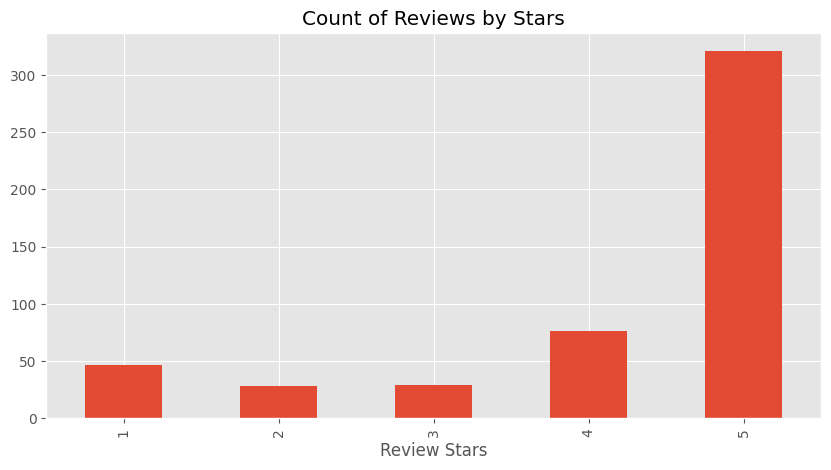

In [ ]:
ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

In [ ]:
example = df['Text'][50]
print(example)

With a legendary name like Gevalia, I was disappointed to find that the coffee contains artificial flavors.  The outside packaging looks gourmet and epicurean, with gold lettering.  Unfortunately, artificial flavoring also plainly occupies the front face.<br /><br />The aroma from the coffee is quite pleasant, however, after brewing, the coffee itself is nothing to write home about.  In fact, it tasted rather bitter.<br /><br />I would not buy this item.


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Now, let's try tokenizing the example text again.

In [ ]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['With',
 'a',
 'legendary',
 'name',
 'like',
 'Gevalia',
 ',',
 'I',
 'was',
 'disappointed']

In [ ]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('With', 'IN'),
 ('a', 'DT'),
 ('legendary', 'JJ'),
 ('name', 'NN'),
 ('like', 'IN'),
 ('Gevalia', 'NNP'),
 (',', ','),
 ('I', 'PRP'),
 ('was', 'VBD'),
 ('disappointed', 'VBN')]

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
import nltk
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [ ]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  With/IN
  a/DT
  legendary/JJ
  name/NN
  like/IN
  (GPE Gevalia/NNP)
  ,/,
  I/PRP
  was/VBD
  disappointed/VBN
  to/TO
  find/VB
  that/IN
  the/DT
  coffee/NN
  contains/VBZ
  artificial/JJ
  flavors/NNS
  ./.
  The/DT
  outside/JJ
  packaging/NN
  looks/VBZ
  gourmet/JJ
  and/CC
  epicurean/JJ
  ,/,
  with/IN
  gold/JJ
  lettering/NN
  ./.
  Unfortunately/RB
  ,/,
  artificial/JJ
  flavoring/NN
  also/RB
  plainly/RB
  occupies/VBZ
  the/DT
  front/NN
  face./NN
  </NNP
  br/NN
  //NNP
  >/NNP
  </NNP
  br/NN
  //NNP
  >/VBZ
  The/DT
  aroma/NN
  from/IN
  the/DT
  coffee/NN
  is/VBZ
  quite/RB
  pleasant/JJ
  ,/,
  however/RB
  ,/,
  after/IN
  brewing/NN
  ,/,
  the/DT
  coffee/NN
  itself/PRP
  is/VBZ
  nothing/NN
  to/TO
  write/VB
  home/NN
  about/IN
  ./.
  In/IN
  fact/NN
  ,/,
  it/PRP
  tasted/VBD
  rather/RB
  bitter./JJ
  </NNP
  br/NN
  //NNP
  >/NNP
  </NNP
  br/NN
  //NNP
  >/NN
  I/PRP
  would/MD
  not/RB
  buy/VB
  this/DT
  item/NN
  ./.)


In [ ]:
import nltk
nltk.download('words')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

# Step 1. VADER Seniment Scoring
We will use NLTK's SentimentIntensityAnalyzer to get the neg/neu/pos scores of the text.

This uses a "bag of words" approach:
Stop words are removed
each word is scored and combined to a total score.

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [ ]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [ ]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [ ]:
sia.polarity_scores(example)

{'neg': 0.073, 'neu': 0.847, 'pos': 0.081, 'compound': 0.1513}

In [ ]:
# Run the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')

In [ ]:
# Now we have sentiment score and metadata
vaders.head()


,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,Time,Score,HelpfulnessNumerator,HelpfulnessDenominator,Summary,Text
0,165257,0.000,0.768,0.232,0.9684,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",2010-03-10,5,0,0,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,0.089,0.766,0.144,0.7920,B0000BXJIS,A3U62RE5XZDP0G,Marty,2011-03-01,5,0,0,Great Kitty Treats,My cat loves these treats. If ever I can't fin...
2,427828,0.000,0.880,0.120,0.4588,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,2008-10-15,3,0,2,Coffee Taste,A little less than I expected. It tends to ha...
3,433955,0.009,0.827,0.163,0.9923,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,2012-04-25,2,0,1,So The Mini-Wheats Were Too Big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,0.089,0.719,0.191,0.9421,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,2012-04-18,5,0,2,Great Taste . . .,and I want to congratulate the graphic artist ...


# Plot VADER results

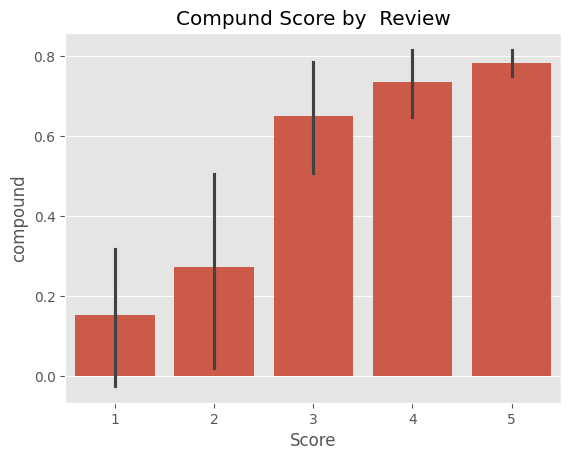

In [ ]:
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compund Score by  Review')
plt.show()

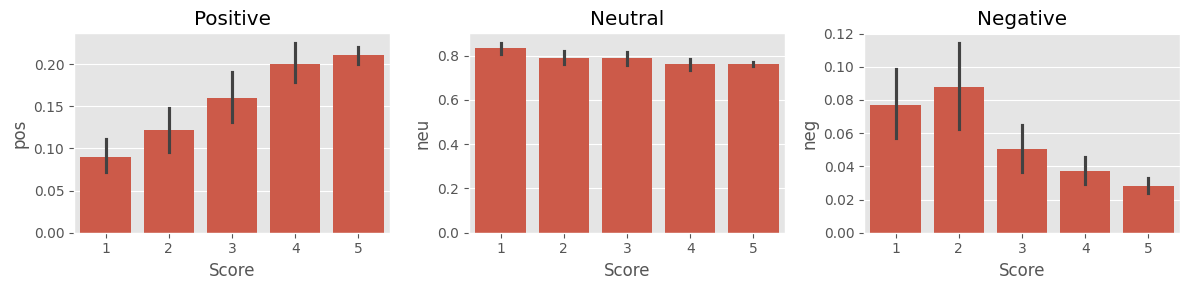

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

# Step 2. Roberta Pretrained Model
Use a model trained of a large corpus of data.
Transformer model accounts for the words but also the context related to other words

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
# VADER results on example
print(example)
sia.polarity_scores(example)

With a legendary name like Gevalia, I was disappointed to find that the coffee contains artificial flavors.  The outside packaging looks gourmet and epicurean, with gold lettering.  Unfortunately, artificial flavoring also plainly occupies the front face.<br /><br />The aroma from the coffee is quite pleasant, however, after brewing, the coffee itself is nothing to write home about.  In fact, it tasted rather bitter.<br /><br />I would not buy this item.


{'neg': 0.073, 'neu': 0.847, 'pos': 0.081, 'compound': 0.1513}

In [ ]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.82845974), 'roberta_neu': np.float32(0.14214098), 'roberta_pos': np.float32(0.029399266)}


In [ ]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [ ]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/500 [00:00<?, ?it/s]

Broke for id 184619
Broke for id 31994
Broke for id 171315
Broke for id 149020


In [33]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

# Compare Scores between models

In [34]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'Time', 'Score', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Summary', 'Text'],
      dtype='object')

# Step 3. Combine and compare

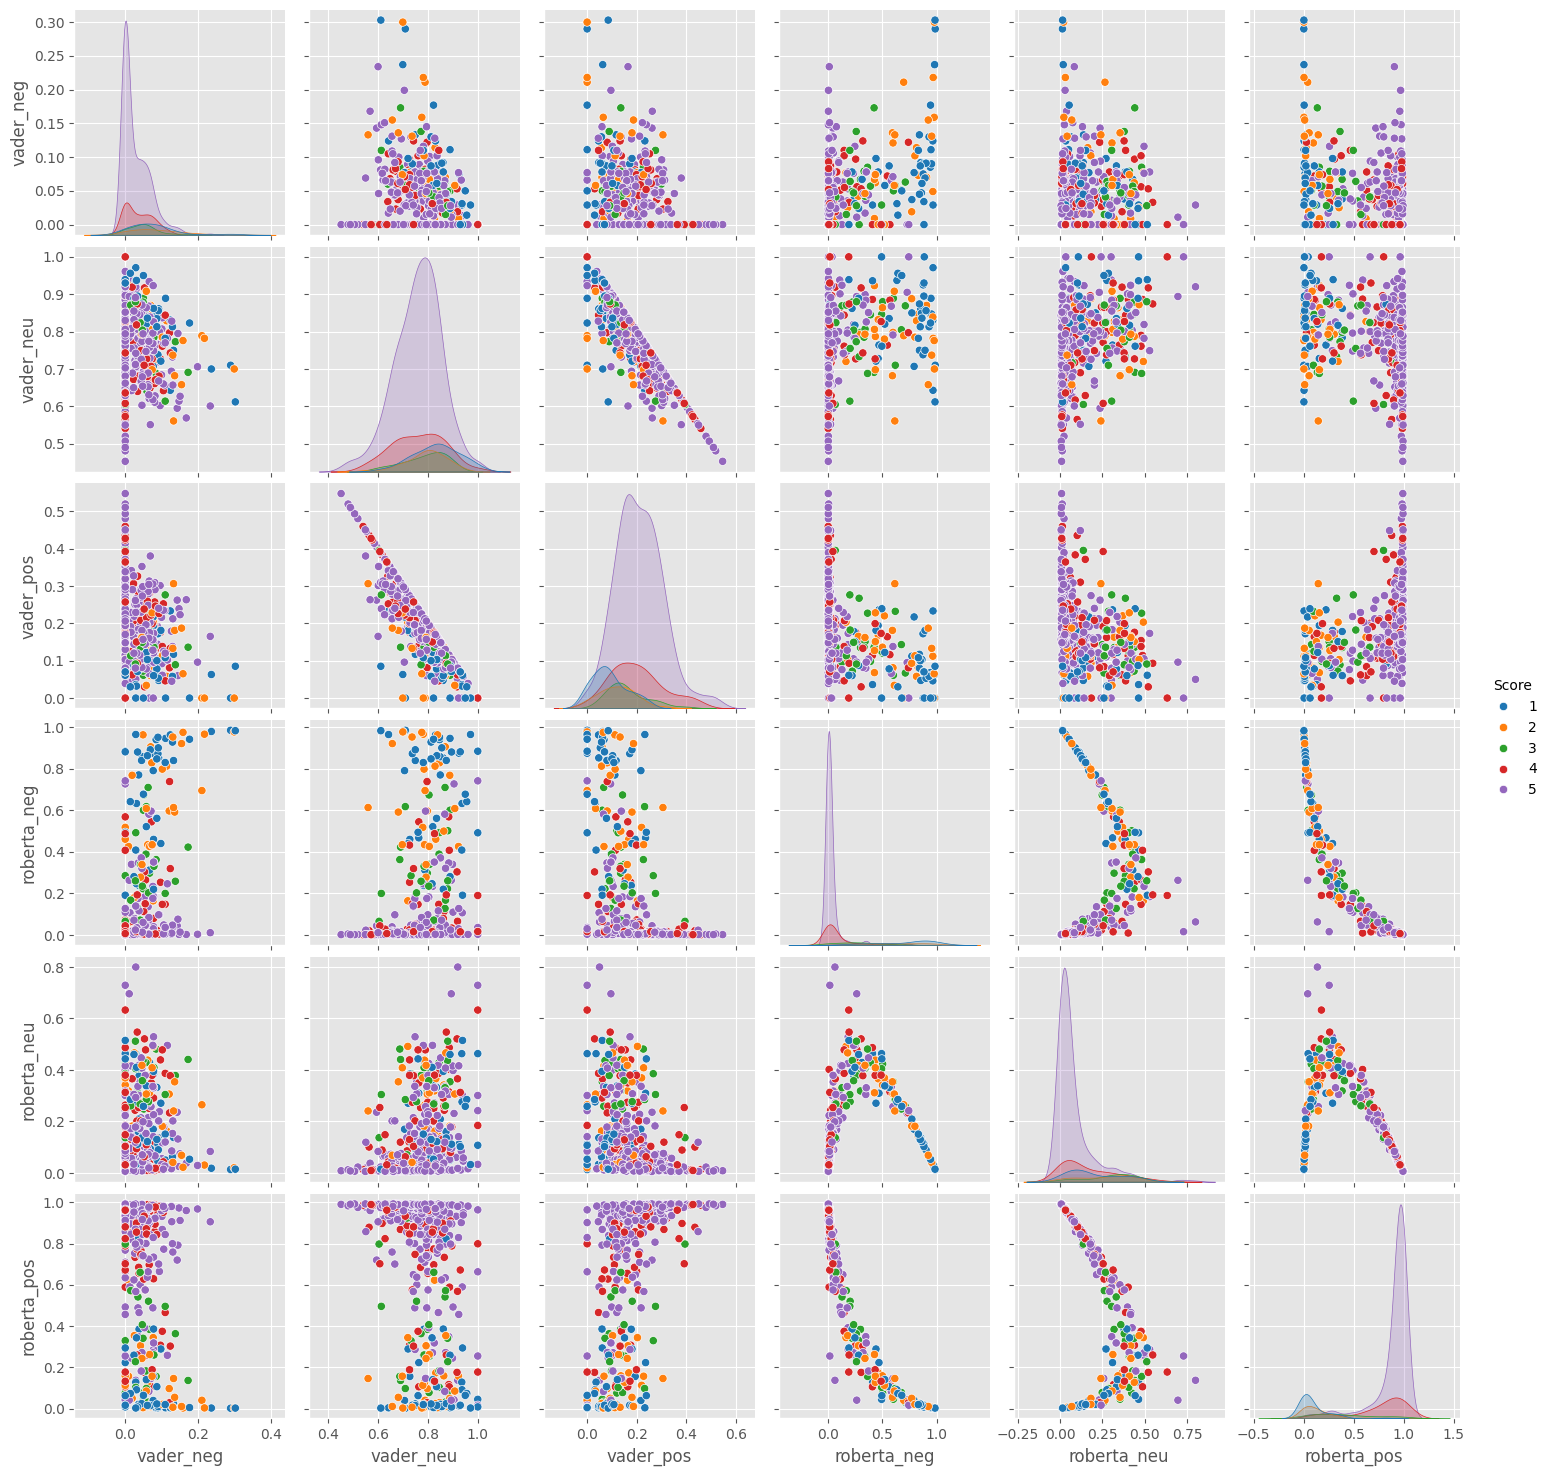

In [37]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

# Step 4: Review Examples
Positive 1-Star and Negative 5-Star Reviews.

Lets look at some examples where the model scoring and review score differ the most.

In [38]:
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

"I've been giving my daughter Gerber fruits, veggies, and meat as everyday-meals since she was 6 months old, thinking that she's got enough vitamins and prebiotics. However, she developed digestive problem and chronic constipation; she almost stopped gaining weight since she was 9 months old. I took her to GI and she told me that those packed fruits are all cooked! And there are additives to keep them fresh for long period of time! I started to puree fruits and veggies using Vitamix, and only use Gerber fruits&veggies when we are out and about. Now, after half a year of probiotics and wholesome food, she's slowly getting better and opens her mouth to food."

In [39]:
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'The ingredients clearly say "evaporated cane juice".  That is sugar.  Amazon needs to change the description.'

In [40]:
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

"My title says it all. Plus, the price per cup has not been equaled anywhere that I've checked."

In [41]:
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'Very smooth, never bitter. Wonderful for me because this is a low acid coffee and if you have problems with heartburn this coffee is a good choice.'

# The Transformers Pipeline
  Quick & easy way to run sentiment predictions





In [42]:
from transformers import pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [45]:
sentiment_pipeline('I love sentiment analysis!')

[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

In [46]:
sentiment_pipeline('Make sure to like and subscribe!')

[{'label': 'POSITIVE', 'score': 0.9991742968559265}]

In [47]:
sentiment_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]

In [48]:
import gradio as gr
from transformers import pipeline

# Load the sentiment analysis model from Hugging Face Transformers.
# This model will download automatically the first time you run the app.
# It's a pre-trained model optimized for sentiment analysis.
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
#sentiment_analyzer = pipeline("sentiment-analysis")

# Define the function that Gradio will use.
# It takes a single text input and returns the sentiment prediction.
def predict_sentiment(text):
    """
    Analyzes the sentiment of a given text.

    Args:
        text (str): The input text to analyze.

    Returns:
        dict: A dictionary containing the predicted sentiment label and score.
    """
    if not text:
        return {"label": "NONE", "score": 0.0}

    # The pipeline returns a list of dictionaries, we just need the first one.
    result = sentiment_analyzer(text)[0]

    # Return the result in a format that Gradio's gr.Label can display.
    # The key and value of the dict correspond to the label and confidence.
    return {result['label']: result['score']}

# Create the Gradio Interface.
# gr.Interface combines the input, output, and function into a web UI.
# The inputs are a Textbox, and the output is a Label.
# We also provide a title, description, and some examples to make it easy to use.
ui = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter your sentence here...",
        label="Input Text"
    ),
    outputs=gr.Label(num_top_classes=1, label="Sentiment"),
    title="Real-Time Sentiment Analysis",
    description="Analyze the sentiment of any text. Try phrases like 'I love this' or 'I am so sad'.",
    examples=[
        ["I am so happy with this project!"],
        ["This movie was a waste of time."],
        ["The service was just okay."]
    ]
)

# Launch the Gradio application.
if __name__ == "__main__":
    ui.launch()

Device set to use cpu


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://77f18739b08e163ae6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
